# T68 — Reference-Frame Uncertainty in Modelled Paleoclimate

**Cluster J: Paleoclimate**

*Based on:* Leonard, J., Zahirovic, S., Holden, P.B., Salles, T., Edwards, N.R. and Mallard, C.A. (2025). *Polar wander leads to large differences in past climate reconstructions*. **Communications Earth & Environment**, 6(1), p.508.

## What this notebook produces

Plate reconstructions are precise in a **relative-motion** sense (plates moving relative to one another), but absolute longitude-latitude positions depend on the chosen **absolute reference frame**. Many different absolute reference frames have been built. Some define absolute plate locations relative to a stationary mantle, while others record locations relative to the paleomagnetic pole. The choice of reference frame can shift reconstructed paleolatitudes by >10°, which in turn changes inferred climate fields.

This notebook reproduces key Leonard et al. (2025) results showing how reference-frame choice propagates into simulated climate.

1. **§3 — Map comparison.** For 5 ages (210, 170, 130, 90, 40 Ma), build a four-panel row: (a) SAT in the Merdith 2021 paleomagnetic frame, (b) SAT in the Müller 2016 hybrid mantle frame, (c) reconstructed-point ΔSAT, (d) reconstructed-point Δ|latitude|.
2. **§4 — Latitude-age heatmaps.** Compare zonal-mean SAT as latitude × age for each frame and their difference.
3. **§5 (bonus) — Global-mean SAT time series.** Compare global average temperatures.

## Learning objectives

- Load and manipulate PLASIM-GENIE outputs (`puma_temperature_surface_air`) with xarray.
- Compare climate fields between two absolute reference frames.
- Reconstruct frame differences to a common present-day indexing grid for like-for-like comparison.
- Build publication-style pyGMT maps and latitude-age diagnostics.

## Prerequisites and runtime

- Bundled data in `data/leonard_2025_paleoclimate/` (~2 MB): 3 frames × 26 ages × 3 variables (SAT, land-sea mask, orography).
- Python packages: `xarray`, `numpy`, `pygmt`, `matplotlib`, `pandas`, `gplately`.
- Runtime: ~30 s for §3, ~5 s for §4, ~2 s for §5 on a typical laptop.

## Sources

- Leonard, J., Zahirovic, S., Holden, P.B., Salles, T., Edwards, N.R. and Mallard, C.A. (2025). Polar wander leads to large differences in past climate reconstructions. *Communications Earth & Environment*, 6(1), p.508.
- Full archive: <https://zenodo.org/records/15628277>.

## Data availability

**Bundled data** (`data/leonard_2025_paleoclimate/`, ~2 MB total):

- `merdith2021_paleomag/{0..250}Ma.nc` — PLASIM-GENIE output recast into the Merdith et al. (2021) paleomagnetic frame.
- `muller2016_mantle/{0..250}Ma.nc` — the same output recast into the Müller et al. (2016) hybrid mantle frame.
- `torsvik2019_paleomag/{0..250}Ma.nc` — optional third frame for comparison.

Each NetCDF has 32 × 64 PLASIM-resolution grids for:

- `puma_temperature_surface_air` (°C, annual mean SAT)
- `grid_landsea_mask` (0-1)
- `grid_orography` (m)

The full Leonard et al. (2025) archive (~384 MB; 5 frames × ~15 variables × 26 ages) is available on Zenodo.

**License:** CC BY 4.0 (Leonard et al. 2025).

## Sources

- Leonard, J., Zahirovic, S., Holden, P.B., Salles, T., Edwards, N.R. and Mallard, C.A. (2025). Polar wander leads to large differences in past climate reconstructions. *Communications Earth & Environment*, 6(1), p.508.
- Merdith, A.S. et al. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477.
- Müller, R.D. et al. (2016). Ocean basin evolution and global-scale plate reorganization events since Pangea breakup. *Annual Review of Earth and Planetary Sciences* 44, 107-138.
- Torsvik, T.H. & Cocks, L.R.M. (2019). *Earth history and palaeogeography*. Cambridge University Press.

## Environment + imports


In [34]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt
import gplately

# House-style Mollweide/Robinson rim fix for coarse GCM output (T64-T67 pattern).
sys.path.insert(0, str(Path("Notebooks").resolve()))
from paleoclimate_helpers import refine_for_plot

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt, gplately):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.14.4
  numpy       2.4.3
  pandas      3.0.2
  xarray      2026.4.0
  pygmt       v0.18.0
  gplately    2.0.0


In [35]:
# === USER CONFIGURATION =====================================================
# Reference frames to compare (folder names under data/leonard_2025_paleoclimate/).
FRAME_A_DIR    = Path("data/leonard_2025_paleoclimate/merdith2021_paleomag")
FRAME_B_DIR    = Path("data/leonard_2025_paleoclimate/muller2016_mantle")
FRAME_A_LABEL  = "Merdith 2021 (paleomagnetic)"
FRAME_B_LABEL  = "Müller 2016 (hybrid mantle)"

# Plate reconstructions
ZAHIROVIC_2022_RECONSTRUCTIONS = Path("data/leonard_2025_paleoclimate/plate_reconstructions/Zahirovic_etal_2022_GDJ_NNR") # Note that this contains absolute reference frames for Merdith 2021 (anchored plate ID 701701), Muller 2016 (anchored plate ID 705705), and Muller 2022 (anchored plate ID 0)
TORSVIK_2019_RECONSTRUCTIONS = Path("data/leonard_2025_paleoclimate/plate_reconstructions/Torsvik_etal_2019") # Note that this contains a mantle reference frame (anchored plate ID 0) and a paleomagnetic reference frame (anchored plate ID 1)

# Anchor IDs for the two Zahirovic-2022 reference-frame casts above.
FRAME_A_ANCHOR_ID = 701701
FRAME_B_ANCHOR_ID = 705705

# The five snapshot ages for the §3 map-comparison grid (matches Leonard 2025 Fig 3)
SNAPSHOT_AGES_MA = [210, 170, 130, 90, 40]

# All ages available in the bundle (0-250 Ma at 10-Myr cadence). Used by §4/§5.
ALL_AGES_MA      = list(range(0, 260, 10))

# Variable to compare — PLASIM annual-mean surface air temperature (°C)
VAR              = "puma_temperature_surface_air"

# Colour-palette path (for pre-made palettes)
AIR_TEMP_CPT = Path("data/windyTemp.cpt")    # air temperature colour palette file adpated from windy.com

# Colour-bar ranges
SAT_RANGE_C      = (-30, 50, 5)     # absolute SAT (°C)
DIFF_RANGE_C     = (-15, 15, 1)     # ΔSAT between frames (°C)
LATDIFF_RANGE    = (-30, 30, 2)     # Δ|latitude| between frames (°)

# Global map projection
REGION           = [-180, 180, -90, 90]
PROJECTION       = "N15c"           # Robinson, 15 cm wide (subplot cell size)
# ============================================================================
print(f"  frame A: {FRAME_A_LABEL}")
print(f"  frame B: {FRAME_B_LABEL}")
print(f"  §3 ages: {SNAPSHOT_AGES_MA}")
print(f"  §4 ages: 0-{max(ALL_AGES_MA)} Ma at 10-Myr cadence")


  frame A: Merdith 2021 (paleomagnetic)
  frame B: Müller 2016 (hybrid mantle)
  §3 ages: [210, 170, 130, 90, 40]
  §4 ages: 0-250 Ma at 10-Myr cadence


## 1. Load the paleoclimate ensemble


In [36]:
def load_frame(frame_dir, ages):
    """Return an xarray.Dataset with dim (age, latitude, longitude) for a frame."""
    slices = []
    for age in ages:
        f = frame_dir / f"{age:03d}Ma.nc"
        if not f.exists(): continue
        ds = xr.open_dataset(f).expand_dims({"age": [age]})
        slices.append(ds)
    return xr.concat(slices, dim="age")

frame_A = load_frame(FRAME_A_DIR, ALL_AGES_MA)
frame_B = load_frame(FRAME_B_DIR, ALL_AGES_MA)
print(f"  Frame A: {dict(frame_A.sizes)}, vars {list(frame_A.data_vars)}")
print(f"  Frame B: {dict(frame_B.sizes)}, vars {list(frame_B.data_vars)}")
print(f"  Frame A SAT range: [{float(frame_A[VAR].min()):.1f}, {float(frame_A[VAR].max()):.1f}] °C")
print(f"  Frame B SAT range: [{float(frame_B[VAR].min()):.1f}, {float(frame_B[VAR].max()):.1f}] °C")


  Frame A: {'age': 26, 'latitude': 32, 'longitude': 64}, vars ['puma_temperature_surface_air', 'grid_landsea_mask', 'grid_orography']
  Frame B: {'age': 26, 'latitude': 32, 'longitude': 64}, vars ['puma_temperature_surface_air', 'grid_landsea_mask', 'grid_orography']
  Frame A SAT range: [-20.6, 50.0] °C
  Frame B SAT range: [-22.2, 50.1] °C


## 2. Reconstructed-point ΔSAT and Δ|latitude| helpers

To fairly assess the differences in climate between reference frames, we can't simply just use the SAT grids of each reference frame because their geographies will be different due to the different reference frames.

To compare fairly, we:

1. Build a gpml file consisting of points that correspond to the location of the centroid of each cell in the climate simulations.
2. Reconstruct those points to the target age in each frame.
3. Sample each paleo field (i.e SAT) at those reconstructed points.
4. Plot those paleo values with the original present-day (i.e non-reconstructed) coordinates.
5. We can then fairly assess the climate differences between reference frames using present-day reconstructed values.


In [ ]:
from gplately import pygplates

def _build_plate_reconstruction(model_dir):
    """Construct a gplately PlateReconstruction from local Z22 files."""
    rotation_model = model_dir / "CombinedRotations.rot"
    topology_features = sorted(model_dir.glob("*.gpml"))
    static_polygons = model_dir / "StaticGeometries/StaticPolygons/Global_EarthByte_GPlates_PresentDay_StaticPlatePolygons.shp"
    
    if not rotation_model.exists():
        raise FileNotFoundError(f"Missing rotation model: {rotation_model}")
    if not topology_features:
        raise FileNotFoundError(f"No topology files found in: {model_dir}")
    if not static_polygons.exists():
        raise FileNotFoundError(f"Missing static polygons: {static_polygons}")

    return gplately.PlateReconstruction(
        rotation_model=str(rotation_model),
        topology_features=[str(p) for p in topology_features],
        static_polygons=str(static_polygons),
    )

def _wrap_lon(lon):
    """Wrap longitudes into the [-180, 180) range."""
    return ((lon + 180.0) % 360.0) - 180.0

def _as_wrapped_lon_da(da):
    """Return DataArray with wrapped/sorted longitude for robust nearest-neighbour sampling."""
    return da.assign_coords(longitude=_wrap_lon(da.longitude)).sortby("longitude")

PLATE_RECON = _build_plate_reconstruction(ZAHIROVIC_2022_RECONSTRUCTIONS)

# Back-end pygplates objects (FIGURES-style GPML reconstruction workflow).
_ROTATION_MODEL_FILE = ZAHIROVIC_2022_RECONSTRUCTIONS / "CombinedRotations.rot"
_STATIC_POLYGONS_FILE = ZAHIROVIC_2022_RECONSTRUCTIONS / "StaticGeometries/StaticPolygons/Global_EarthByte_GPlates_PresentDay_StaticPlatePolygons.shp"
_ROTATION_MODEL = pygplates.RotationModel(str(_ROTATION_MODEL_FILE))
_STATIC_POLYGONS = pygplates.FeatureCollection(str(_STATIC_POLYGONS_FILE))

# Fixed present-day output grid (this is the common indexing space).
_PRESENT_LATS = frame_A.latitude.values
_PRESENT_LONS = _wrap_lon(frame_A.longitude.values)
_PRESENT_LON2D, _PRESENT_LAT2D = np.meshgrid(_PRESENT_LONS, _PRESENT_LATS)
_N_PRESENT = _PRESENT_LON2D.size

# Cache reconstructed centroid coordinates for (age, anchor).
_GPML_RECON_CACHE = {}

def _build_global_gpml_points():
    """Create present-day centroid points and attach plate IDs (global_gpml_ebyte pattern)."""
    features = []
    for i, (lon, lat) in enumerate(zip(_PRESENT_LON2D.ravel(), _PRESENT_LAT2D.ravel())):
        feat = pygplates.Feature(pygplates.FeatureType.gpml_unclassified_feature)
        feat.set_geometry(pygplates.PointOnSphere(float(lat), float(lon)))
        feat.set_name(str(i))  # preserves fixed output indexing
        features.append(feat)

    points_fc = pygplates.FeatureCollection(features)
    assigned = pygplates.partition_into_plates(
        _STATIC_POLYGONS,
        _ROTATION_MODEL,
        points_fc,
        properties_to_copy=[
            pygplates.PartitionProperty.reconstruction_plate_id,
            pygplates.PartitionProperty.valid_time_period,
        ],
        reconstruction_time=0,
    )
    return pygplates.FeatureCollection(assigned)

_GLOBAL_GPML_POINTS = _build_global_gpml_points()

def diff_field(fa, fb, var=VAR):
    """Native-grid difference (quick reference only)."""
    return (fa[var] - fb[var]).rename(f"delta_{var}")

def _reconstruct_global_gpml_to_age(age_ma, anchor_plate_id):
    """Reconstruct GPML centroid points to age_ma and return lon/lat arrays indexed by feature name."""
    key = (float(age_ma), int(anchor_plate_id))
    if key in _GPML_RECON_CACHE:
        return _GPML_RECON_CACHE[key]

    recon_pts = []
    pygplates.reconstruct(
        _GLOBAL_GPML_POINTS,
        _ROTATION_MODEL,
        recon_pts,
        reconstruction_time=float(age_ma),
        anchor_plate_id=int(anchor_plate_id),
    )

    rlons = np.full(_N_PRESENT, np.nan, dtype=float)
    rlats = np.full(_N_PRESENT, np.nan, dtype=float)
    for pt in recon_pts:
        try:
            idx = int(pt.get_feature().get_name())
            lat, lon = pt.get_reconstructed_geometry().to_lat_lon_list()[0]
            rlons[idx] = _wrap_lon(float(lon))
            rlats[idx] = float(lat)
        except Exception:
            continue

    _GPML_RECON_CACHE[key] = (rlons, rlats)
    return _GPML_RECON_CACHE[key]

def reconstruct_field_to_present(field_at_age, age_ma, anchor_plate_id):
    """Sample paleo field at reconstructed centroid positions, then write to present-day index grid."""
    da = _as_wrapped_lon_da(field_at_age)
    rlons, rlats = _reconstruct_global_gpml_to_age(age_ma, anchor_plate_id)

    out_flat = np.full(_N_PRESENT, np.nan, dtype=float)
    valid = np.isfinite(rlons) & np.isfinite(rlats)
    if np.any(valid):
        sample = da.sel(
            longitude=xr.DataArray(rlons[valid], dims="points"),
            latitude=xr.DataArray(rlats[valid], dims="points"),
            method="nearest",
        ).values
        sample = np.asarray(sample).ravel()

        idx = np.nonzero(valid)[0]
        good = np.isfinite(sample)
        out_flat[idx[good]] = sample[good]

    return xr.DataArray(
        out_flat.reshape(_PRESENT_LON2D.shape),
        dims=("latitude", "longitude"),
        coords={"latitude": _PRESENT_LATS, "longitude": _PRESENT_LONS},
        name=field_at_age.name or VAR,
    )

def lat_diff_present_day(age_ma):
    """Δ|latitude| = |lat_A| - |lat_B| on the same present-day centroid index grid."""
    _, rlats_a = _reconstruct_global_gpml_to_age(age_ma, FRAME_A_ANCHOR_ID)
    _, rlats_b = _reconstruct_global_gpml_to_age(age_ma, FRAME_B_ANCHOR_ID)
    out_flat = np.full(_N_PRESENT, np.nan, dtype=float)

    valid = np.isfinite(rlats_a) & np.isfinite(rlats_b)
    if np.any(valid):
        out_flat[valid] = np.abs(rlats_a[valid]) - np.abs(rlats_b[valid])

    return xr.DataArray(
        out_flat.reshape(_PRESENT_LON2D.shape),
        dims=("latitude", "longitude"),
        coords={"latitude": _PRESENT_LATS, "longitude": _PRESENT_LONS},
        name="delta_abs_latitude",
    )

def diff_field_present_day(fa, fb, age_ma, var=VAR):
    """ΔSAT = Frame A - Frame B after reconstruction onto the common present-day index grid."""
    a_present = reconstruct_field_to_present(
        fa[var], age_ma=age_ma, anchor_plate_id=FRAME_A_ANCHOR_ID
    )
    b_present = reconstruct_field_to_present(
        fb[var], age_ma=age_ma, anchor_plate_id=FRAME_B_ANCHOR_ID
    )
    return (a_present - b_present).rename(f"delta_{var}")

# Quick sanity check at one reference age.
_dsat_native = diff_field(frame_A.sel(age=170), frame_B.sel(age=170))
_dsat_present = diff_field_present_day(frame_A.sel(age=170), frame_B.sel(age=170), age_ma=170)
_dlat_present = lat_diff_present_day(age_ma=170)
print(f"  170 Ma native-grid ΔSAT range: [{float(_dsat_native.min()):.1f}, {float(_dsat_native.max()):.1f}] °C, "
      f"mean {float(_dsat_native.mean()):.2f} °C")
print(f"  170 Ma reconstructed-grid ΔSAT range: [{float(_dsat_present.min()):.1f}, {float(_dsat_present.max()):.1f}] °C, "
      f"mean {float(_dsat_present.mean()):.2f} °C")
print(f"  170 Ma reconstructed-grid Δ|latitude| range: [{float(_dlat_present.min(skipna=True)):.1f}, {float(_dlat_present.max(skipna=True)):.1f}] °")

  170 Ma native-grid ΔSAT range: [-17.7, 11.3] °C, mean -0.21 °C
  170 Ma reconstructed-grid ΔSAT range: [-12.2, 13.5] °C, mean 0.44 °C
  170 Ma reconstructed-grid Δ|latitude| range: [-4.3, 4.3] °


## 3. Map comparison — five ages × four columns

For each age in `SNAPSHOT_AGES_MA`, render one row with:

- **Col 1** — Frame A SAT (`AIR_TEMP_CPT`) + coastlines contoured from Frame A land-sea mask.
- **Col 2** — Frame B SAT (`AIR_TEMP_CPT`) + coastlines contoured from Frame B land-sea mask.
- **Col 3** — Reconstructed-point ΔSAT = Frame A − Frame B (fixed range −20 to 20 °C).
- **Col 4** — Reconstructed-point Δ|latitude| = |lat_A| − |lat_B| (fixed range −20 to 20°).

Together, columns 3 and 4 show where frame-dependent paleoposition changes are likely to drive temperature differences.

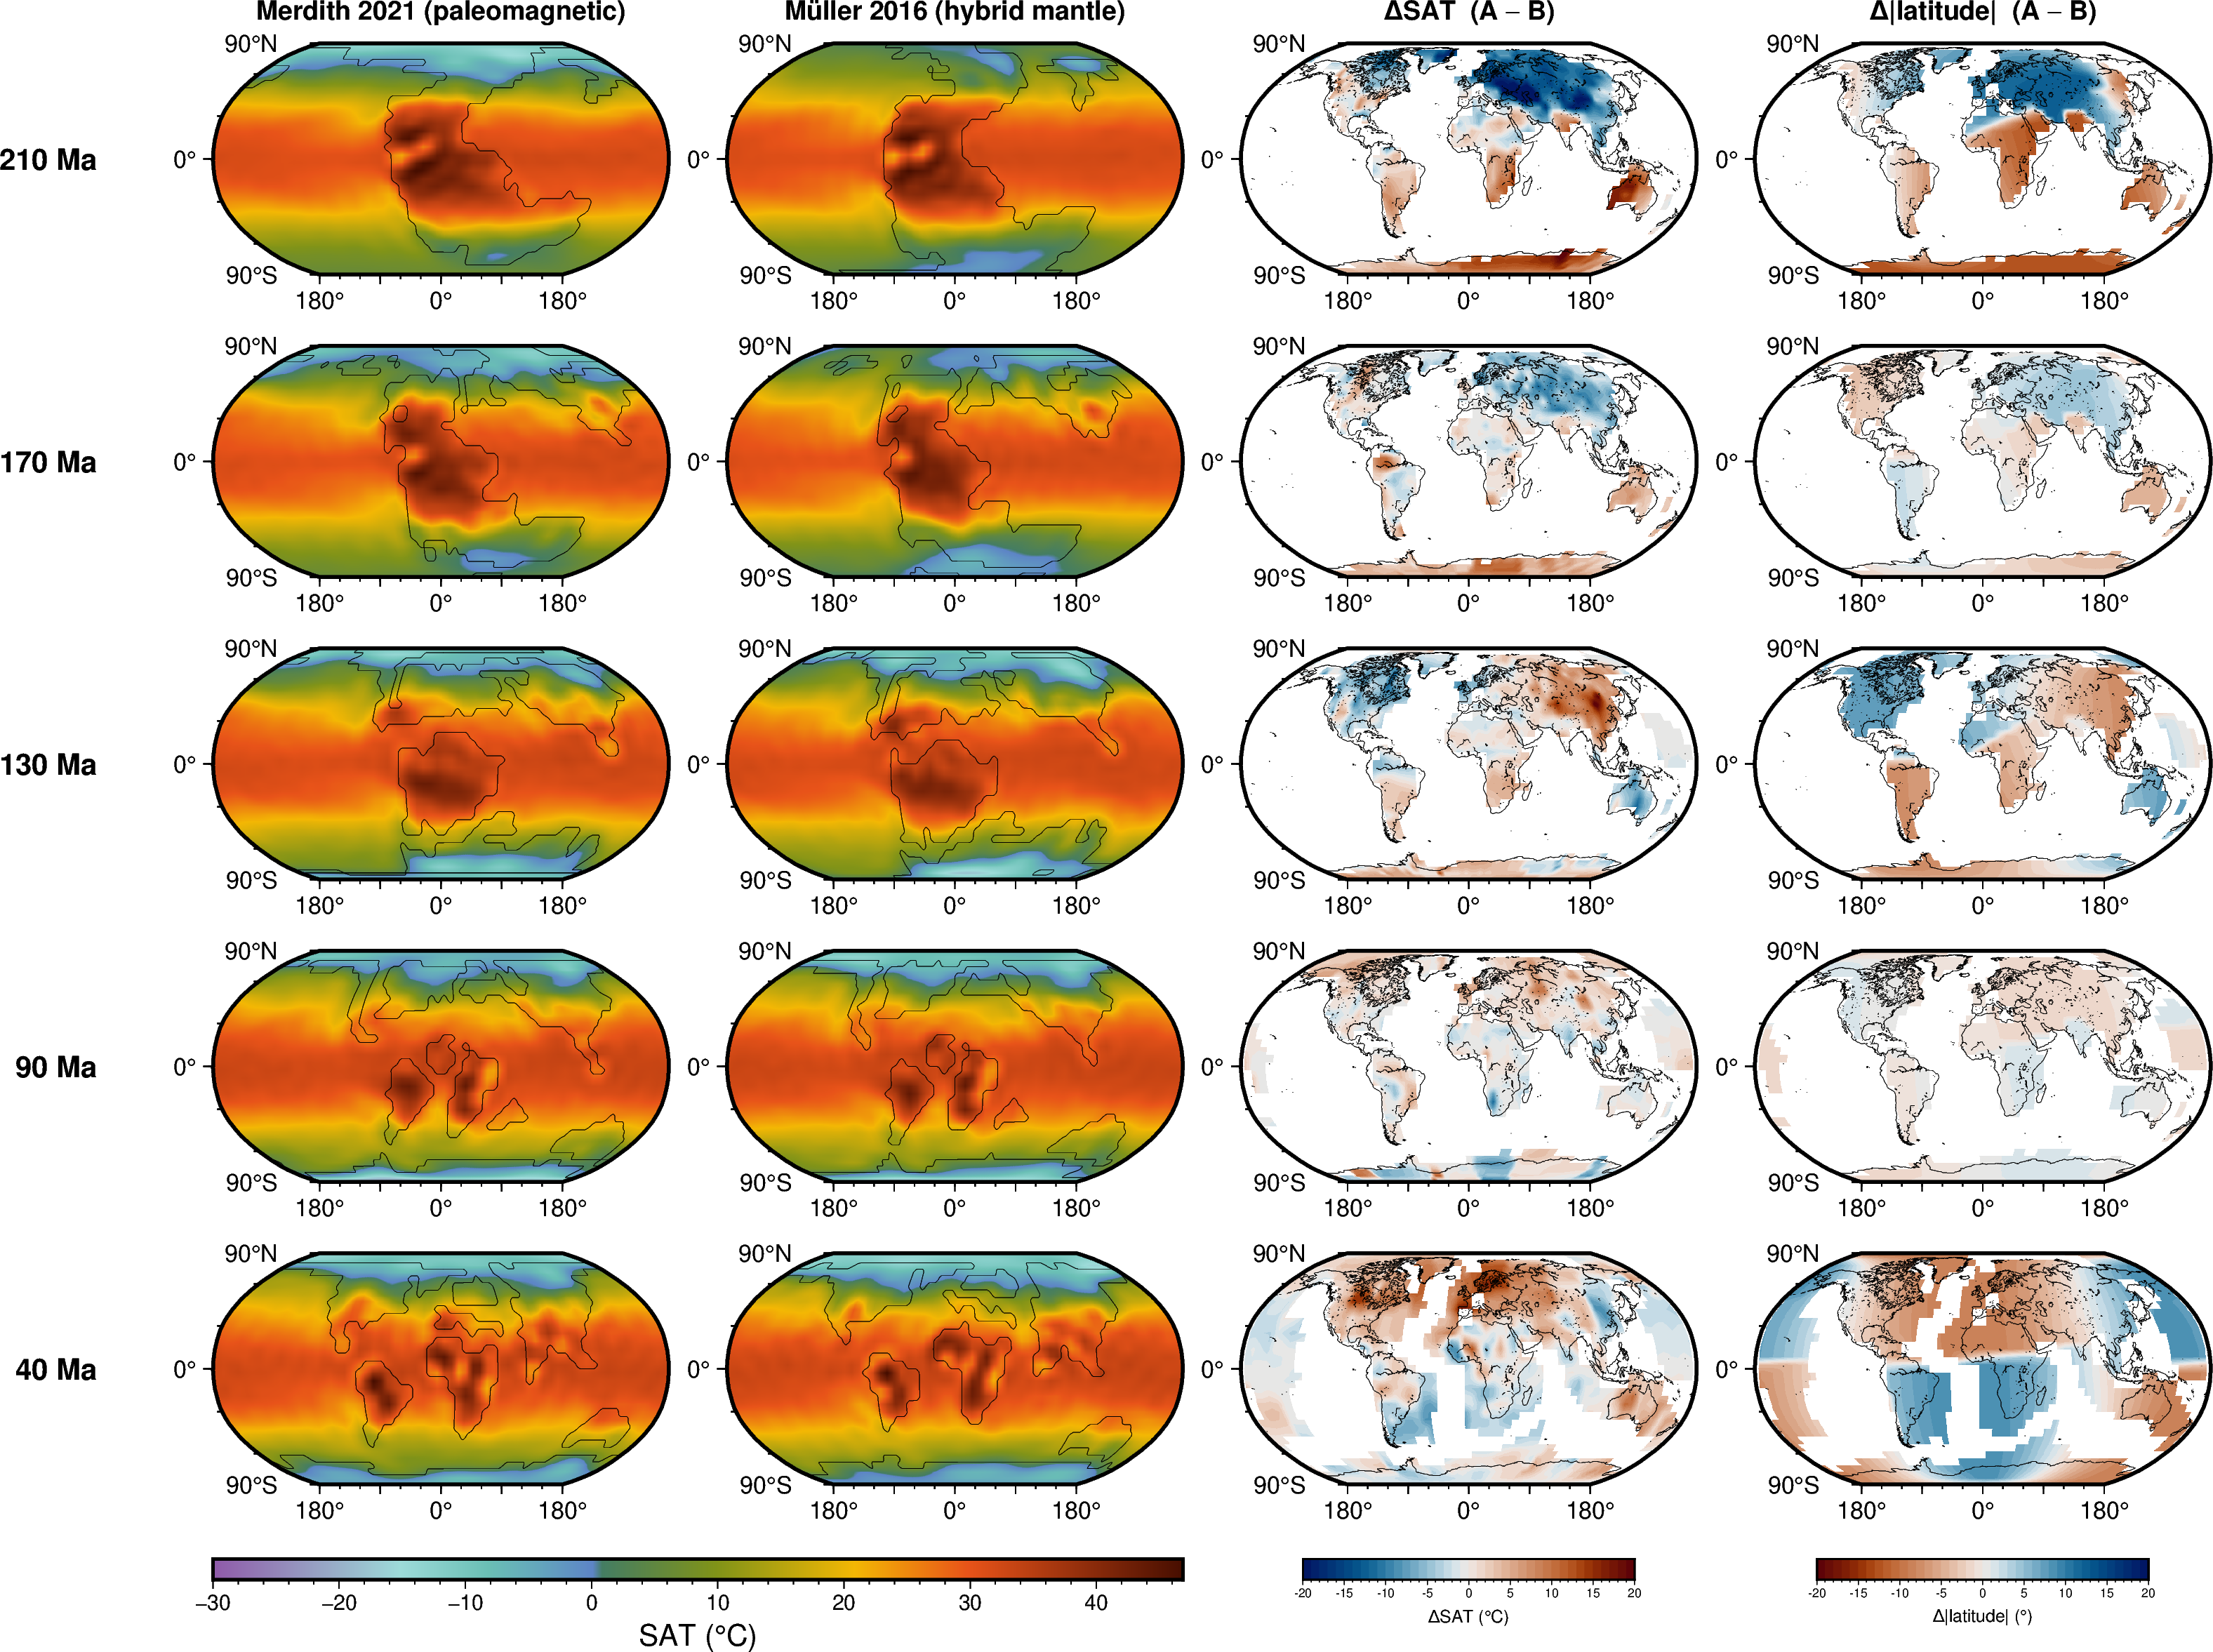

In [ ]:
PANEL_W_CM = 5.5             # Robinson width per panel (cm)
PANEL_H_CM = PANEL_W_CM / 2  # Robinson aspect ~2:1
COL_GAP_CM = 0.7             # horizontal gap between columns
ROW_GAP_CM = 0.9             # vertical gap between rows
DX_CM = PANEL_W_CM + COL_GAP_CM # horizontal shift between columns
DY_CM = PANEL_H_CM + ROW_GAP_CM # vertical shift between rows

PANEL_PROJ = f"N{PANEL_W_CM}c"
COL_TITLES = [FRAME_A_LABEL, FRAME_B_LABEL, "ΔSAT  (A − B)", "Δ|latitude|  (A − B)"]

# Pre-build cpts (one per column)
CPT_SAT   = str(AIR_TEMP_CPT)
CPT_DIFF  = "diff.cpt"
CPT_LATF  = "latf.cpt"
DIFF_AND_LAT_RANGE = [-20, 20, 1]
pygmt.makecpt(cmap="vik",  series=DIFF_AND_LAT_RANGE, background="o", output=CPT_DIFF)
pygmt.makecpt(cmap="vik", series=DIFF_AND_LAT_RANGE, background="o", reverse=True, output=CPT_LATF)
CPTS_FOR_COL = [CPT_SAT, CPT_SAT, CPT_DIFF, CPT_LATF]

fig = pygmt.Figure()

# Iterate rows TOP-to-BOTTOM (row 0 = 210 Ma at top, row 4 = 40 Ma at bottom).
# Draw across a row left-to-right, then shift_origin back to col 0 and down one
# row height before the next row.
n_rows = len(SNAPSHOT_AGES_MA)
for row, age in enumerate(SNAPSHOT_AGES_MA):
    fa_sat = refine_for_plot(frame_A[VAR].sel(age=age),
                             lon_name="longitude", lat_name="latitude")
    fb_sat = refine_for_plot(frame_B[VAR].sel(age=age),
                             lon_name="longitude", lat_name="latitude")
    dsat_raw = diff_field_present_day(frame_A.sel(age=age), frame_B.sel(age=age), age_ma=age)
    dsat = refine_for_plot(dsat_raw, lon_name="longitude", lat_name="latitude")
    dlat_raw = lat_diff_present_day(age_ma=age)
    dlat = refine_for_plot(dlat_raw, lon_name="longitude", lat_name="latitude")
    
    # Age-appropriate coastlines from each frame's land-sea mask (0.5 contour).
    coast_a = refine_for_plot(frame_A["grid_landsea_mask"].sel(age=age),
                              lon_name="longitude", lat_name="latitude")
    coast_b = refine_for_plot(frame_B["grid_landsea_mask"].sel(age=age),
                              lon_name="longitude", lat_name="latitude")
    
    fields = [fa_sat, fb_sat, dsat, dlat]

    for col, field in enumerate(fields):
        # Draw one Robinson panel
        fig.grdimage(grid=field, cmap=CPTS_FOR_COL[col],
                     region=REGION, projection=PANEL_PROJ, frame="af")

        # Columns 1-2: age-appropriate coastlines from the frame-specific land-sea mask.
        if col == 0:
            fig.grdcontour(grid=coast_a, levels=[0.5], pen="0.15p,black",
                           region=REGION, projection=PANEL_PROJ)
        elif col == 1:
            fig.grdcontour(grid=coast_b, levels=[0.5], pen="0.15p,black",
                           region=REGION, projection=PANEL_PROJ)
        else:
            # Columns 3-4 retain present-day coastlines as geographic reference.
            fig.coast(region=REGION, projection=PANEL_PROJ,
                      shorelines="0.15p,black")

        # Row label on the leftmost panel of every row
        if col == 0:
            fig.text(text=f"{age} Ma", position="ML",
                     offset="-1.4c/0c", justify="MR",
                     font="10p,Helvetica-Bold,black", no_clip=True,
                     region=REGION, projection=PANEL_PROJ)

        # Column title only on the top row
        if row == 0:
            fig.text(text=COL_TITLES[col], position="TC",
                     offset="0/0.4c", justify="MC",
                     font="9p,Helvetica-Bold,black", no_clip=True,
                     region=REGION, projection=PANEL_PROJ)

        # Bottom-row colorbars
        if row == n_rows - 1:
            # Shared SAT colorbar spanning columns 1-2
            if col == 1:
                fig.colorbar(
                    cmap=CPT_SAT,
                    position=f"JBC+w{(2 * PANEL_W_CM + COL_GAP_CM):.2f}c/0.25c+h+o-{DX_CM / 2:.2f}c/0.9c",
                    frame=["af", "x+lSAT (°C)"],
                )
            # Column-3 colorbar (ΔSAT)
            if col == 2:
                fig.colorbar(
                    cmap=CPT_DIFF,
                    position="JBC+w4c/0.25c+h+o0/0.9c",
                    frame=["a5f1", "x+lΔSAT (°C)"],
                )
            # Column-4 colorbar (Δ|latitude|)
            if col == 3:
                fig.colorbar(
                    cmap=CPT_LATF,
                    position="JBC+w4c/0.25c+h+o0/0.9c",
                    frame=["a5f1", "x+lΔ|latitude| (°)"],
                )

        # Move origin RIGHT to the next column (except after the last)
        if col < 3:
            fig.shift_origin(xshift=f"{DX_CM}c")

    # Carriage return: back to col 0, down one row height (except after last row)
    if row < n_rows - 1:
        fig.shift_origin(xshift=f"-{3 * DX_CM}c", yshift=f"-{DY_CM}c")

fig.show(width=1000)

### How to read the map grid

**Interpretation note for outreach use**

These maps are designed to isolate **geographic/reference-frame effects**. They are not full paleoclimate reconstructions because key forcings (for example CO2 and insolation history) are not evolving realistically in this demonstration setup.

- **Column 3 (ΔSAT = A − B)**: red means the paleomagnetic frame is warmer than the mantle frame at that reconstructed-point location; blue means cooler.
- **Column 4 (Δ|latitude| = |lat_A| − |lat_B|)**: red means Frame A is closer to the equator than Frame B; blue means closer to the pole.

Age-by-age guide:

- **210 Ma (Triassic, Pangea)** — Large coherent shifts are common because continents are still largely amalgamated.
- **170–90 Ma (Jurassic-Cretaceous breakup)** — Differences become patchier as plate motions diversify.
- **40 Ma (Eocene)** — It would be expected that differences minimise as we approach recent times, however the 40 Ma example shows how large differences persist into the Cenozoic.

What to watch for:

- **Magnitude**: |ΔSAT| of 5–10 °C is common and often regionally larger.
- **Consistency through time**: track one region and ask whether differences persist in one sign or oscillate around zero.
- **Coupling between columns 3 and 4**: stronger latitude offsets usually align with stronger SAT offsets.

## 4. Comparing zonal-mean temperatures

Longitude-averaging each grid gives a zonal (latitude-only) temperature profile at each age. Stacking those profiles through time produces a latitude × age heatmap.

This view emphasises the latitude control on temperature and shows where reference-frame differences create systematic hemispheric bias.

Three panels:

- **Frame A** — Merdith 2021 paleomagnetic zonal-mean SAT
- **Frame B** — Müller 2016 mantle zonal-mean SAT
- **Difference** — Frame A − Frame B zonal-mean SAT

/Users/jono/opt/anaconda3/envs/pyPlasimGenie/lib/python3.14/site-packages/pygmt/clib/session.py:1648: RuntimeWarning: Grid may have irregular spacing in the 'y' dimension, but GMT only supports regular spacing. Calculated regular spacing -5.5329413414001465 is assumed in the 'y' dimension.


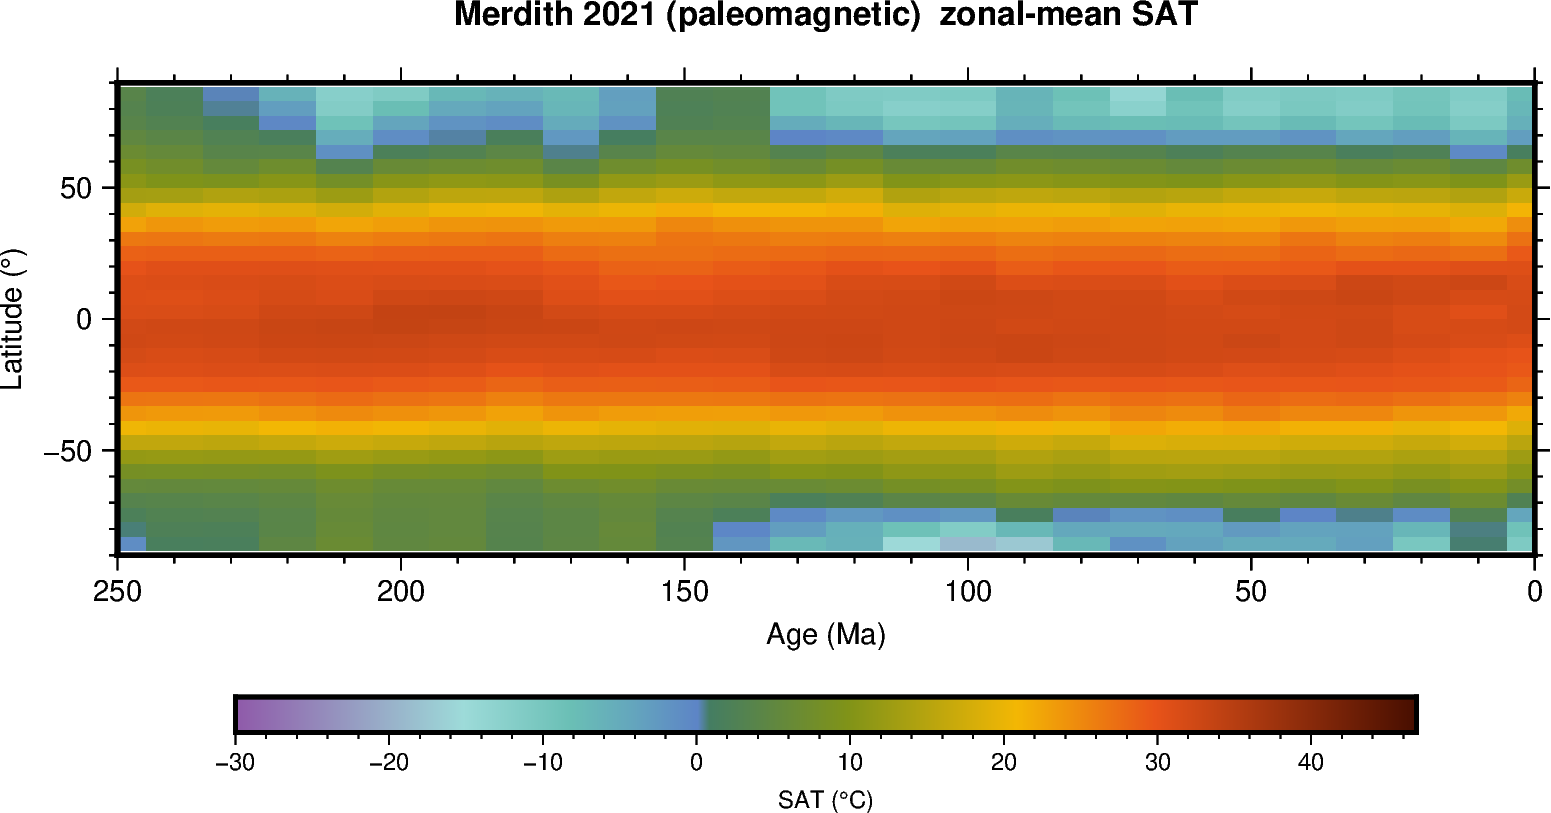

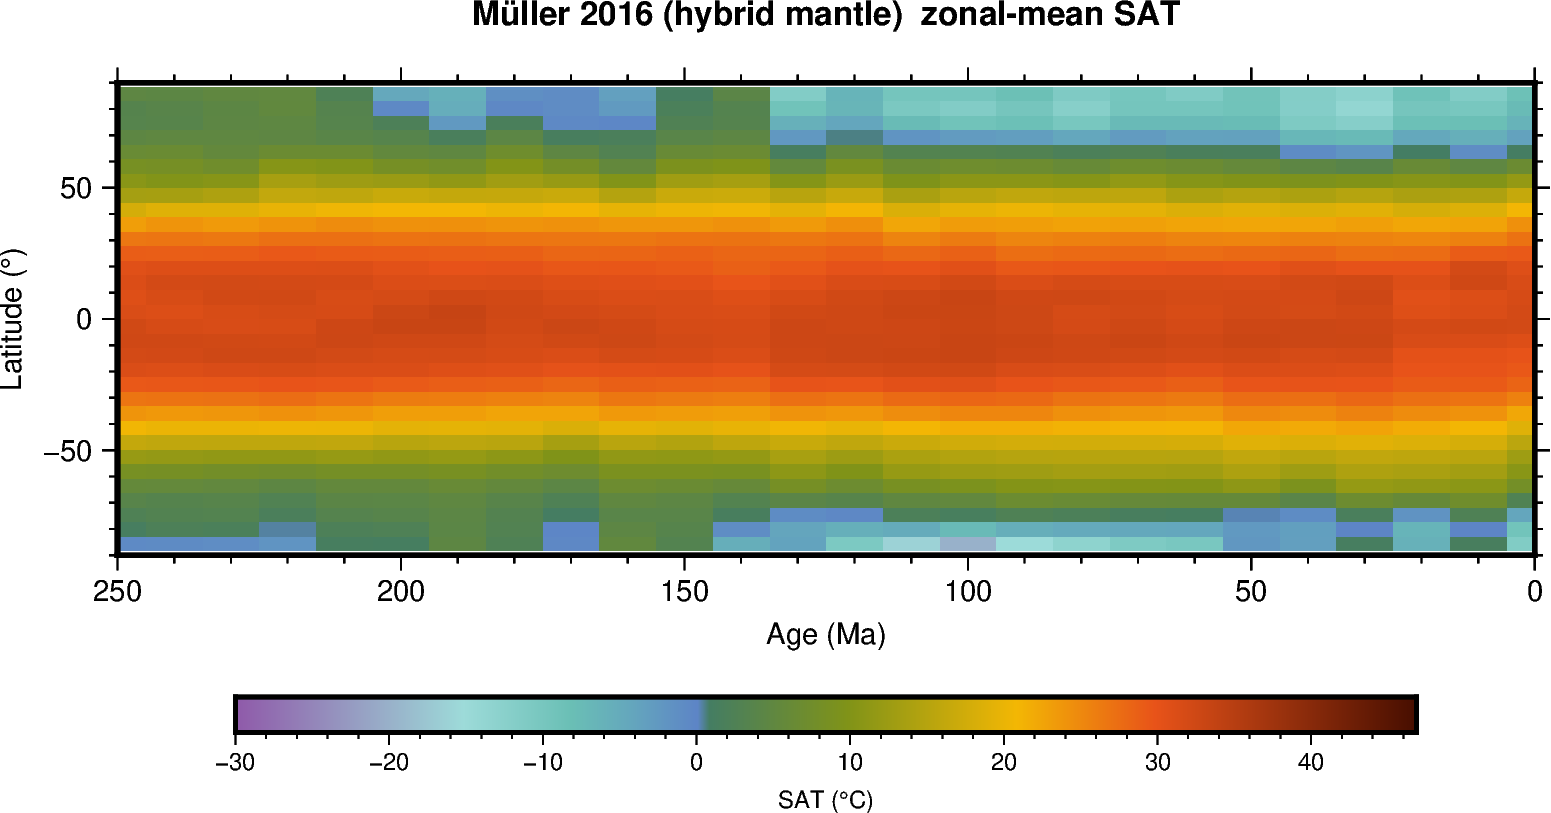

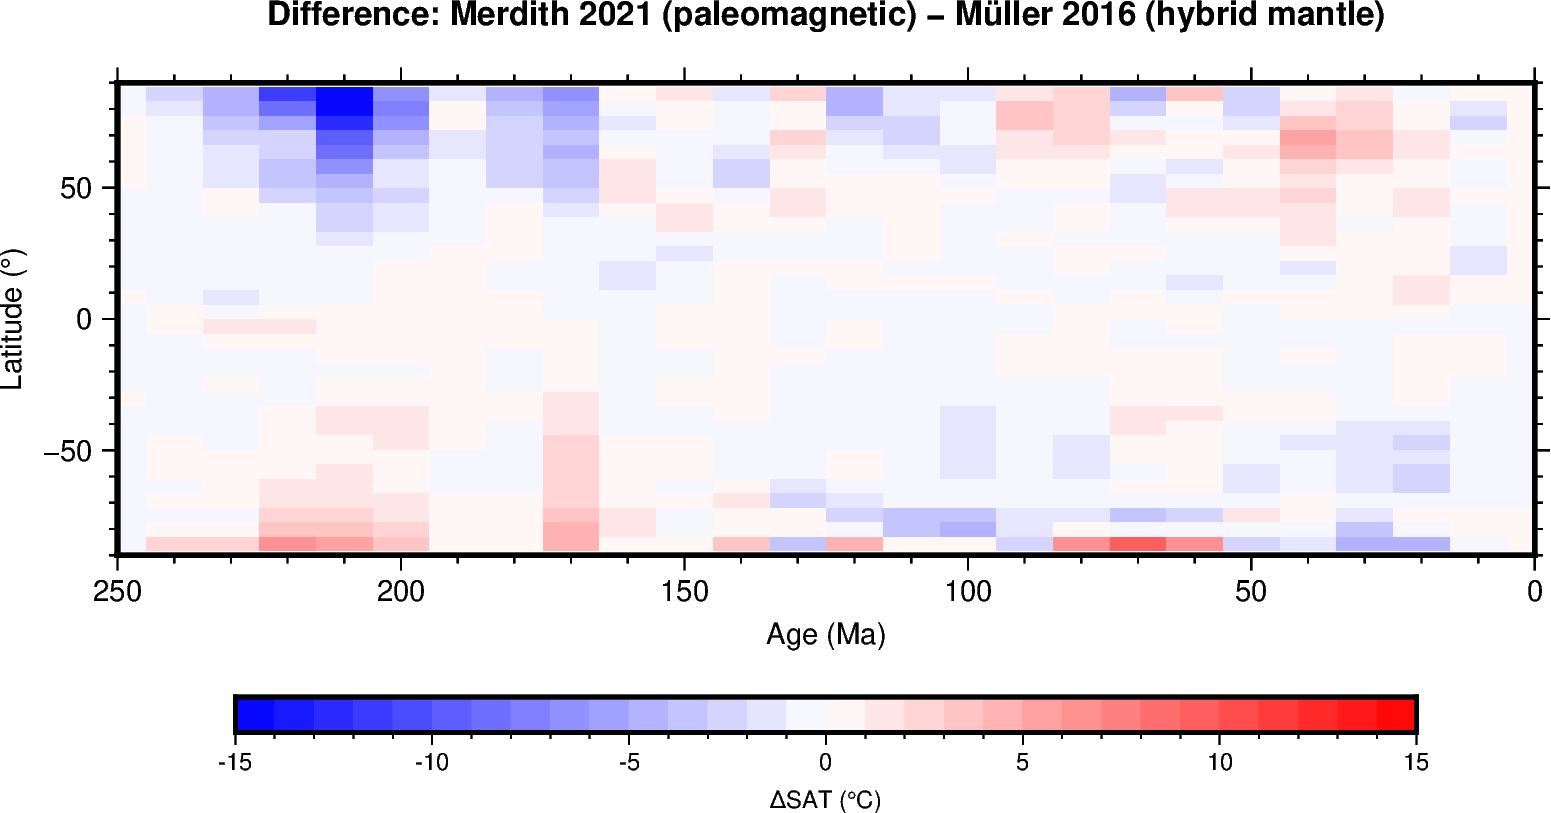

In [79]:
# Zonal (longitude-mean) SAT per frame — turned into pyGMT grdimages
zonal_A = frame_A[VAR].mean(dim="longitude")   # (age, lat)
zonal_B = frame_B[VAR].mean(dim="longitude")
zonal_D = zonal_A - zonal_B

# Each of these is a 2-D grid; wrap as xarray DataArray with proper dim naming
# for pygmt.grdimage. Coord "age" → x-axis, "latitude" → y-axis.
def as_grid(da, name):
    """Return a (lat, age)-ordered DataArray with x/y dim names pyGMT expects."""
    g = da.rename({"age": "x", "latitude": "y"}).transpose("y", "x")
    g.name = name
    return g

gA = as_grid(zonal_A, "sat_A")
gB = as_grid(zonal_B, "sat_B")
gD = as_grid(zonal_D, "sat_diff")

# Three side-by-side heatmap panels — separate pygmt.Figure per panel (house style)
REG_SAT  = [0, float(zonal_A.age.max()), -90, 90]   # x-inverted (older left)
REG_DIFF = [0, float(zonal_A.age.max()), -90, 90]
PROJ = "X-12c/4c"


# Frame A
fig = pygmt.Figure()
pygmt.config(FONT_TITLE="8p,Helvetica-Bold,black", FONT_ANNOT_PRIMARY="7p,Helvetica,black", FONT_LABEL="7p,Helvetica,black")
fig.grdimage(grid=gA, cmap=CPT_SAT, region=REG_SAT, projection=PROJ,
             frame=["WSne+t" + FRAME_A_LABEL + "  zonal-mean SAT",
                    "xaf+lAge (Ma)", "yaf+lLatitude (°)"])
fig.colorbar(position="JBC+w10c/0.3c+h+o0/1.2c", frame=["a10f2", "x+lSAT (°C)"])
fig.show(width=750)

# Frame B
fig = pygmt.Figure()
pygmt.config(FONT_TITLE="8p,Helvetica-Bold,black", FONT_ANNOT_PRIMARY="7p,Helvetica,black", FONT_LABEL="7p,Helvetica,black")
fig.grdimage(grid=gB, cmap=CPT_SAT, region=REG_SAT, projection=PROJ,
             frame=["WSne+t" + FRAME_B_LABEL + "  zonal-mean SAT",
                    "xaf+lAge (Ma)", "yaf+lLatitude (°)"])
fig.colorbar(position="JBC+w10c/0.3c+h+o0/1.2c", frame=["a10f2", "x+lSAT (°C)"])
fig.show(width=750)

# Difference
fig = pygmt.Figure()
pygmt.config(FONT_TITLE="8p,Helvetica-Bold,black", FONT_ANNOT_PRIMARY="7p,Helvetica,black", FONT_LABEL="7p,Helvetica,black")
pygmt.makecpt(cmap="polar", series=[-15, 15, 1], background="o")
fig.grdimage(grid=gD, cmap=True, region=REG_DIFF, projection=PROJ,
             frame=["WSne+tDifference: " + FRAME_A_LABEL + " − " + FRAME_B_LABEL,
                    "xaf+lAge (Ma)", "yaf+lLatitude (°)"])
fig.colorbar(position="JBC+w10c/0.3c+h+o0/1.2c", frame=["a5f1", "x+lΔSAT (°C)"])
fig.show(width=750)


### How to read the heatmaps

- **Top and middle panels** show each frame separately; both retain the expected warm-equator/cool-pole structure.
- **Bottom panel** shows Frame A − Frame B. A near-zero panel would indicate strong frame agreement; coherent red/blue bands indicate frame-dependent paleolatitude shifts affecting climate.

What to watch for:

- **Persistent hemispheric bands** through time (systematic frame bias).
- **Age windows with large amplitude differences** presumably due to reference frame driven geographic differences.
- **High-latitude contrasts**, where geography/ice-albedo style feedbacks often amplify temperature response. E.g. 210 Ma northern cold bias in the paleomagnetic reference frame is due to more landmass covering the polar areas, and vice versa in the southern hemisphere.

## 5. Bonus — global mean SAT time series

We can plot how the global mean surface temperature of each reference frame tracks with time. We see that with the exception of the 220 - 190 Ma time period where polar landmasses drive discrepencies, in general temperature differences tend to average out globally. Reference frames lead to substantial regional climatic differences, but limited global ones.


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/Publications/pygmt_gplately_Muller2026/GPlately-pyGMT-tutorials/data/leonard_2025_paleoclimate/merdith2021_paleomag/000Ma.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
/Users/jono/opt/anaconda3/envs/pyPlasimGenie/lib/python3.14/site-packages/pygmt/clib/session.py:1648: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing -5.5329413414001465 is assumed in the 'latitude' dimension.
grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/Publications/pygmt_gplately_Muller2026/GPlately-pyGMT-tutorials/data/leonard_2025_paleoclimate/muller2016_mantle/000Ma.nc is not constant.
grdinfo [WARNING]: GMT will

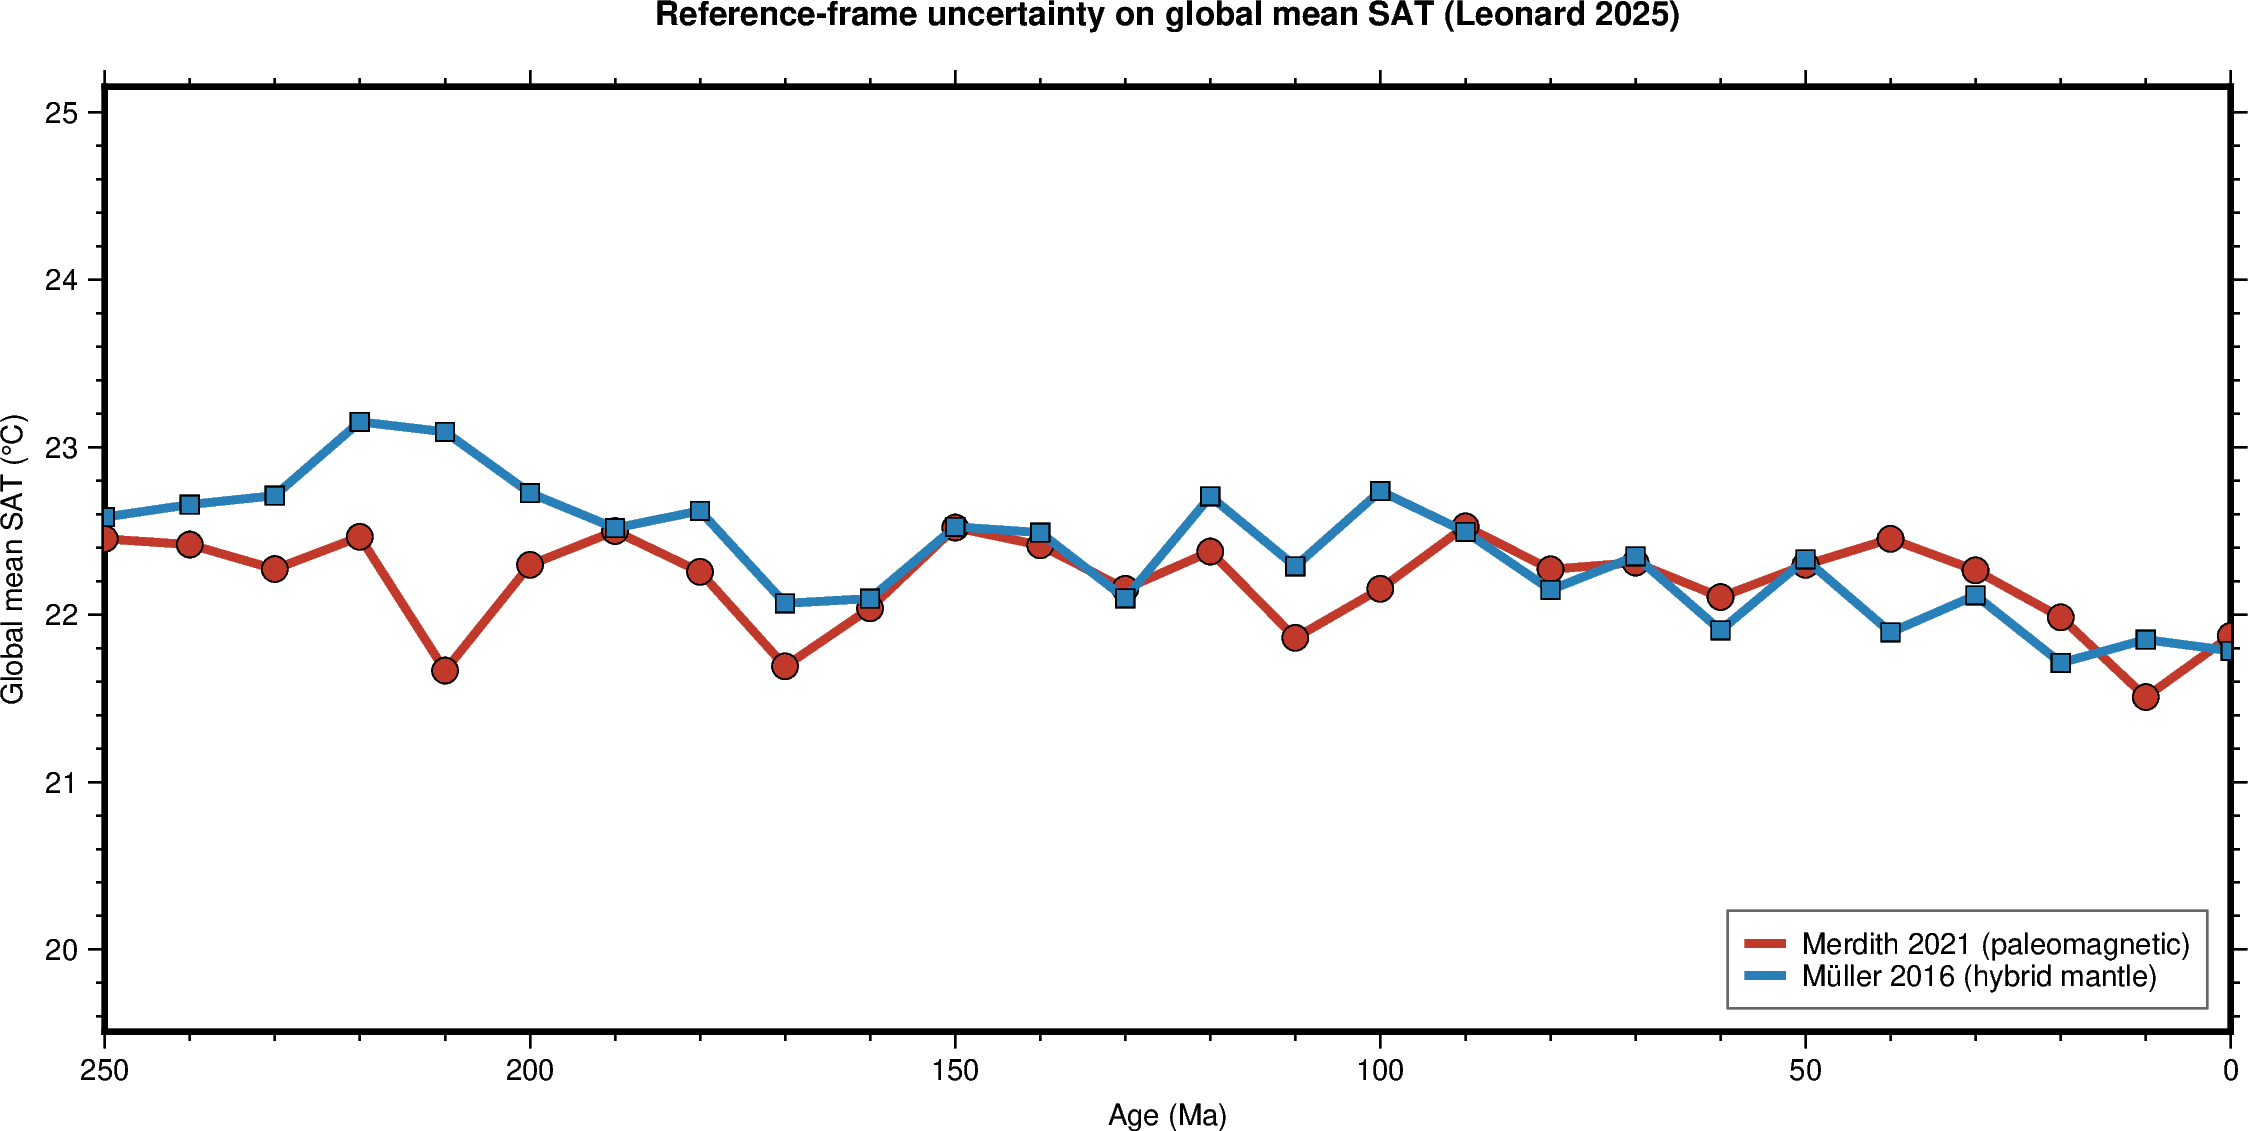


  Mean |GMST gap| between frames: 0.29 °C
  Max  |GMST gap| between frames: 1.43 °C


In [111]:
# Get area weighted means using grdinfo (pyGMT) 
gmst_A = {}
gmst_B = {}
for age in ALL_AGES_MA:
    g = frame_A[VAR].sel(age=age)
    info = pygmt.grdinfo(grid=g, per_column=True, force_scan='2')
    mean = round(float(info.split()[10]), 4)
    gmst_A[age] = mean

    g = frame_B[VAR].sel(age=age)
    info = pygmt.grdinfo(grid=g, per_column=True, force_scan='2')
    mean = round(float(info.split()[10]), 4)
    gmst_B[age] = mean

# Convert to xarray.DataArray for easier plotting
gmst_A = xr.DataArray(
       [gmst_A[age] for age in sorted(gmst_A)],
       coords={"age": sorted(gmst_A)},
       dims="age",
       name="gmst_A",
)
gmst_B = xr.DataArray(
       [gmst_B[age] for age in sorted(gmst_B)],
       coords={"age": sorted(gmst_B)},
       dims="age",
       name="gmst_B",
)

fig = pygmt.Figure()
pygmt.config(FONT_TITLE="8p,Helvetica-Bold,black", FONT_ANNOT_PRIMARY="7p,Helvetica,black", FONT_LABEL="7p,Helvetica,black")

Y_MIN = min(float(gmst_A.min()), float(gmst_B.min())) - 2
Y_MAX = max(float(gmst_A.max()), float(gmst_B.max())) + 2

fig.basemap(
       region=[0, float(gmst_A.age.max()), Y_MIN, Y_MAX],
       projection="X-18c/8c",
       frame=[
              "WSne+tReference-frame uncertainty on global mean SAT (Leonard 2025)",
              "xa50f10+lAge (Ma)",
              "yaf+lGlobal mean SAT (°C)",
       ],
)

# Frame A curve
fig.plot(x=gmst_A.age.values, y=gmst_A.values,
         pen="2p,#c0392b", label=FRAME_A_LABEL)
fig.plot(x=gmst_A.age.values, y=gmst_A.values,
         style="c0.22c", fill="#c0392b", pen="0.3p,black")

# Frame B curve
fig.plot(x=gmst_B.age.values, y=gmst_B.values,
         pen="2p,#2980b9", label=FRAME_B_LABEL)
fig.plot(x=gmst_B.age.values, y=gmst_B.values,
         style="s0.22c", fill="#2980b9", pen="0.3p,black")

fig.legend(position="JBR+jBR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)

# Headline
mean_gap = float(np.mean(np.abs(gmst_B.values - gmst_A.values)))
max_gap  = float(np.max(np.abs(gmst_B.values - gmst_A.values)))
print(f"\n  Mean |GMST gap| between frames: {mean_gap:.2f} °C")
print(f"  Max  |GMST gap| between frames: {max_gap:.2f} °C")


## Extend this

- **Swap Frame B** to `muller2022_optimised_mantle` or `torsvik2019_mantle` to test mantle-frame sensitivity.
- **Swap Frame A** to `torsvik2019_paleomag` to compare paleomagnetic frames directly.
- **Regional focus**: set `REGION` to a subdomain (for example Tethys-focused windows) and reduce ages to a targeted interval.
- **Scale up**: use the full Leonard et al. archive to compare additional variables (for example precipitation).

## Related resources

- Leonard et al. (2025) Zenodo archive: <https://zenodo.org/records/15628277>
- Companion notebooks: **T64**, **T65**, **T66**, **T67**

## References

- Leonard, J., Zahirovic, S., Holden, P.B., Salles, T., Edwards, N.R. and Mallard, C.A. (2025). Polar wander leads to large differences in past climate reconstructions. *Communications Earth & Environment*, 6(1), p.508.
- Merdith, A.S., Williams, S.E., Collins, A.S., Tetley, M.G., Mulder, J.A., Blades, M.L., et al. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477.
- Müller, R.D., Seton, M., Zahirovic, S., Williams, S.E., Matthews, K.J., Wright, N.M., et al. (2016). Ocean basin evolution and global-scale plate reorganization events since Pangea breakup. *Annual Review of Earth and Planetary Sciences* 44, 107-138.
- Torsvik, T.H. & Cocks, L.R.M. (2019). *Earth history and palaeogeography*. Cambridge University Press.
- Holden, P.B., Edwards, N.R., Fraedrich, K., Kirk, E., Lunkeit, F. & Zhu, X. (2016). PLASIM-GENIE v1.0: a new intermediate complexity AOGCM. *Geoscientific Model Development* 9(9), 3347-3361.